Cell 1: Imports & Setup

In [1]:
# GOAL:
#   Import the necessary libraries for data loading, visualization, PCA,
#   correlation checks, classification, and regression.

# WHY:
#   We need these libraries to handle a large dataset (pandas),
#   perform EDA (seaborn, matplotlib), do PCA (sklearn),
#   and build ML models (sklearn).

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


Cell 2: Load & Merge the CSV Files

In [2]:
# GOAL:
#   Merge the 7 CSV parts (~42,000 samples) into a single DataFrame.

# WHY:
#   We want a unified dataset for consistent correlation checks, PCA, and modeling.

data_dir = "../dataset/UWB-LOS-NLOS-Data-Set/dataset/"  # Adjust if your notebook is in "models/" or a different location
csv_files = glob.glob(os.path.join(data_dir, "uwb_dataset_part*.csv"))

df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

uwb_df = pd.concat(df_list, ignore_index=True)

print(f"Merged {len(csv_files)} files.")
print("Total rows:", len(uwb_df))
print("Columns:", uwb_df.columns.tolist())

# Quick preview
uwb_df.head()


Merged 7 files.
Total rows: 42000
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR0', 'CIR1', 'CIR2', 'CIR3', 'CIR4', 'CIR5', 'CIR6', 'CIR7', 'CIR8', 'CIR9', 'CIR10', 'CIR11', 'CIR12', 'CIR13', 'CIR14', 'CIR15', 'CIR16', 'CIR17', 'CIR18', 'CIR19', 'CIR20', 'CIR21', 'CIR22', 'CIR23', 'CIR24', 'CIR25', 'CIR26', 'CIR27', 'CIR28', 'CIR29', 'CIR30', 'CIR31', 'CIR32', 'CIR33', 'CIR34', 'CIR35', 'CIR36', 'CIR37', 'CIR38', 'CIR39', 'CIR40', 'CIR41', 'CIR42', 'CIR43', 'CIR44', 'CIR45', 'CIR46', 'CIR47', 'CIR48', 'CIR49', 'CIR50', 'CIR51', 'CIR52', 'CIR53', 'CIR54', 'CIR55', 'CIR56', 'CIR57', 'CIR58', 'CIR59', 'CIR60', 'CIR61', 'CIR62', 'CIR63', 'CIR64', 'CIR65', 'CIR66', 'CIR67', 'CIR68', 'CIR69', 'CIR70', 'CIR71', 'CIR72', 'CIR73', 'CIR74', 'CIR75', 'CIR76', 'CIR77', 'CIR78', 'CIR79', 'CIR80', 'CIR81', 'CIR82', 'CIR83', 'CIR84', 'CIR85', 'CIR86', 'CIR87', 'CIR88', 'CIR8

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


Cell 3: Basic Inspection & Data Cleaning

In [3]:
# GOAL:
#   Inspect the dataset shape, descriptive stats, and handle any missing or duplicate data.

# WHY:
#   Ensuring data integrity is critical before correlation checks or PCA.

print("Data shape:", uwb_df.shape)

# Descriptive stats (limit columns shown if you have 1000+ columns)
with pd.option_context('display.max_columns', 20):
    print("\nDescriptive Stats (some columns may be truncated):\n", uwb_df.describe())

# Check missing values
missing_counts = uwb_df.isnull().sum()
missing_counts_nonzero = missing_counts[missing_counts > 0]
print("\nMissing values (non-zero):\n", missing_counts_nonzero)

# Example cleaning: drop rows with missing
if not missing_counts_nonzero.empty:
    uwb_df.dropna(inplace=True)
    print("Data shape after dropping rows with missing values:", uwb_df.shape)

# Optional: check duplicates
uwb_df.drop_duplicates(inplace=True)
print("Data shape after removing duplicates:", uwb_df.shape)


Data shape: (42000, 1031)

Descriptive Stats (some columns may be truncated):
                NLOS         RANGE        FP_IDX       FP_AMP1       FP_AMP2  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.000000   
mean       0.500000      3.831519    745.654167   8127.521905  11425.259524   
std        0.500006      2.355976      4.505024   5393.330697   6235.434769   
min        0.000000      0.000000    707.000000      7.000000     63.000000   
25%        0.000000      1.810000    744.000000   3573.750000   5322.750000   
50%        0.500000      3.480000    746.000000   7140.000000  12318.000000   
75%        1.000000      5.420000    748.000000  12273.000000  17310.000000   
max        1.000000     28.020000    848.000000  20572.000000  20624.000000   

            FP_AMP3   STDEV_NOISE       CIR_PWR     MAX_NOISE       RXPACC  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.00000   
mean    9738.106048     72.284571   9789.690214   131

Cell 4: Correlation Check Among the 13 Core Features

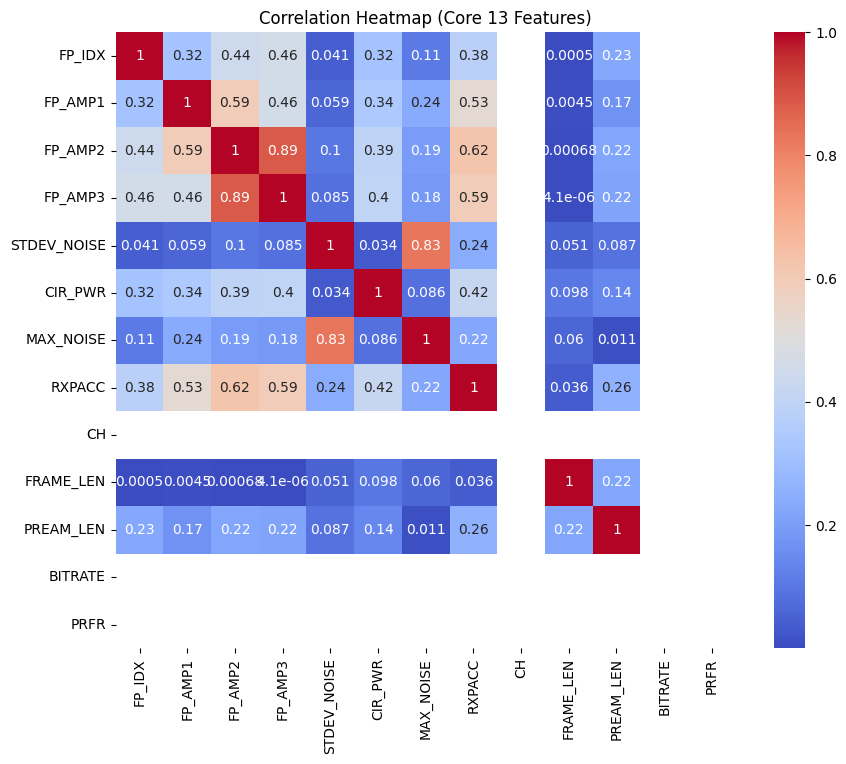

In [4]:
# GOAL:
#   Identify and optionally remove highly correlated core features
#   among these 13 columns (excluding NLOS and RANGE).

# WHY:
#   Redundant features can be dropped if correlation is above a threshold
#   (e.g., 0.80), preventing them from skewing modeling.

core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3", 
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC", 
    "CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"
]

# 1. Correlation matrix for these 13
corr_core = uwb_df[core_features].corr().abs()

# 2. Plot heatmap (may be large but let's do it)
plt.figure(figsize=(10,8))
sns.heatmap(corr_core, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Core 13 Features)")
plt.show()

# Reason:
#   This heatmap visually identifies pairs of features that are highly correlated.
#   If correlation > threshold (e.g., 0.80), we remove one to reduce redundancy.


Cell 5: Checking Unique Values & Data Types for CH, BITRATE, PRFR

In [5]:
# GOAL:
#   Inspect the unique values, data types, and descriptive stats of CH, BITRATE, PRFR.

# WHY:
#   If these columns are constant or have almost no variation, they provide no predictive power
#   and won't correlate with anything. Also, we confirm they are numeric.

print("Unique CH values:", uwb_df["CH"].unique())
print("Unique BITRATE values:", uwb_df["BITRATE"].unique())
print("Unique PRFR values:", uwb_df["PRFR"].unique())

print("\nData Types:\n", uwb_df[["CH", "BITRATE", "PRFR"]].dtypes)
print("\nDescriptive Stats:\n", uwb_df[["CH", "BITRATE", "PRFR"]].describe())

# Reason:
#   If any column shows a single unique value or zero std, it's effectively constant.
#   Such columns can be dropped. If they're non-numeric, we must convert or drop them
#   before correlation or modeling.


Unique CH values: [2.]
Unique BITRATE values: [110.]
Unique PRFR values: [64.]

Data Types:
 CH         float64
BITRATE    float64
PRFR       float64
dtype: object

Descriptive Stats:
             CH  BITRATE     PRFR
count  42000.0  42000.0  42000.0
mean       2.0    110.0     64.0
std        0.0      0.0      0.0
min        2.0    110.0     64.0
25%        2.0    110.0     64.0
50%        2.0    110.0     64.0
75%        2.0    110.0     64.0
max        2.0    110.0     64.0


Cell 6: Correlation with RANGE for MAX_NOISE vs. STDEV_NOISE

In [6]:
# GOAL:
#   Check which of MAX_NOISE or STDEV_NOISE correlates more strongly (in absolute terms)
#   with the regression target RANGE.

# WHY:
#   If two features are correlated with each other, we only keep the one that better
#   explains RANGE for regression tasks.

corr_with_range = uwb_df[["MAX_NOISE", "STDEV_NOISE", "RANGE"]].corr()
print(corr_with_range["RANGE"])

# Reason:
#   The output shows correlation with RANGE:
#   - If |MAX_NOISE| > |STDEV_NOISE|, keep MAX_NOISE (drop STDEV_NOISE).
#   - If the opposite, keep STDEV_NOISE.
#   This approach picks the more predictive feature for range estimation.


MAX_NOISE     -0.260065
STDEV_NOISE    0.089544
RANGE          1.000000
Name: RANGE, dtype: float64


Cell 7: Correlation with RANGE for FP_AMP2 vs. FP_AMP3

In [7]:
# GOAL:
#   Compare how strongly FP_AMP2 and FP_AMP3 each correlate with RANGE
#   to decide which one to keep if they're highly correlated.

# WHY:
#   If FP_AMP2 and FP_AMP3 are redundant, we keep the one that shows
#   stronger correlation (in absolute value) with the target RANGE.

corr_with_range_amp = uwb_df[["FP_AMP2", "FP_AMP3", "RANGE"]].corr()
print(corr_with_range_amp["RANGE"])

# Reason:
#   - If |FP_AMP2| > |FP_AMP3|, keep FP_AMP2 (drop FP_AMP3).
#   - If |FP_AMP3| > |FP_AMP2|, keep FP_AMP3.
#   This data-driven choice helps ensure the better explanatory feature remains.


FP_AMP2   -0.479689
FP_AMP3   -0.459521
RANGE      1.000000
Name: RANGE, dtype: float64


Cell 8: Remove Redundant & Correlated Features

Dropped features: ['CH', 'BITRATE', 'PRFR']
Remaining core features: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN']
Number of remaining core features: 10


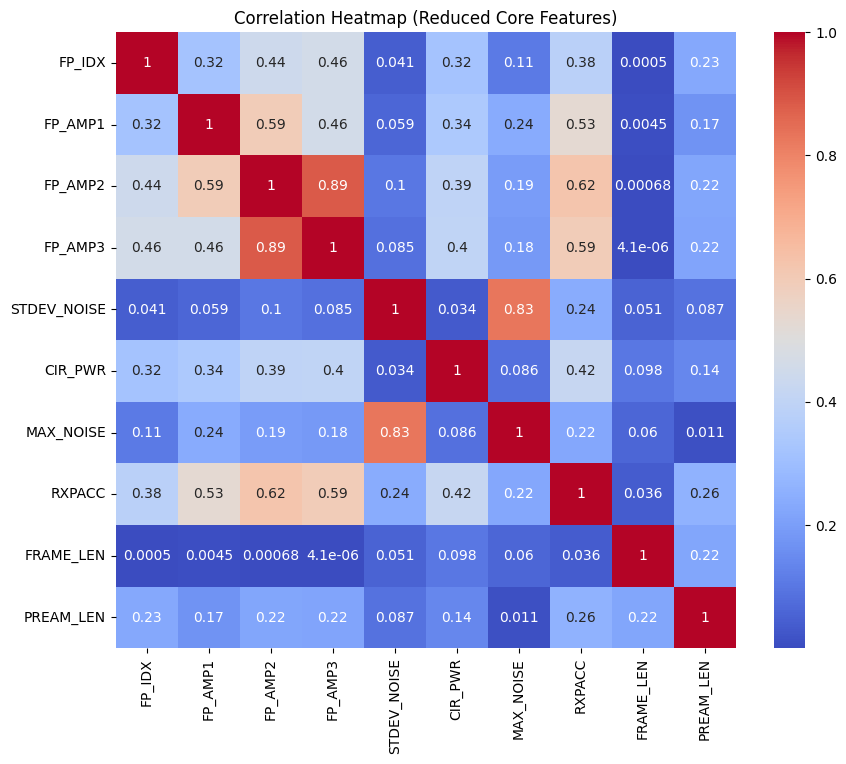

In [10]:
# GOAL:
#   Remove the identified 5 features from the core feature list, show how many remain,
#   then re-plot the correlation heatmap on the reduced set.

# WHY:
#   We want to ensure we've successfully removed redundant/constant features,
#   and verify that the remaining features have acceptable correlation levels.

# 1. Define the features to drop
features_to_drop = ["CH", "BITRATE", "PRFR"]

# 2. Remove them from your core feature list
final_core_features = [f for f in core_features if f not in features_to_drop]

print("Dropped features:", features_to_drop)
print("Remaining core features:", final_core_features)
print("Number of remaining core features:", len(final_core_features))

# 3. Re-check correlation on the remaining features
reduced_corr = uwb_df[final_core_features].corr().abs()

# 4. Plot the updated heatmap
plt.figure(figsize=(10,8))
sns.heatmap(reduced_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Reduced Core Features)")
plt.show()


Cell 9: Load and Normalize CIR Data

In [11]:
# GOAL:
#   Load the full set of CIR features (CIR0..CIR1015) plus RXPACC from multiple CSV files,
#   merge them into one DataFrame, and normalize the CIR columns by dividing by RXPACC.

# WHY:
#   The dataset's instructions recommend dividing CIR values by RXPACC (the number of
#   received preamble symbols) to obtain a per-preamble-pulse measure. This ensures
#   consistent CIR scaling across different samples that might have different RXPACC counts.

cir_columns = [f'CIR{i}' for i in range(1016)]

cir_df = pd.DataFrame()
first = 1
for dirpath, _, filenames in os.walk(data_dir):
    for file in filenames:
        filename = os.path.join(dirpath, file)
        oneFileDF = pd.read_csv(filename, usecols=cir_columns + ['RXPACC'])
        if first > 0:
            first = 0
            cir_df = oneFileDF
        else:
            cir_df = pd.concat([cir_df, oneFileDF], ignore_index=True)

# Normalize the CIR columns by dividing each row's CIR data by its RXPACC value
cir_df[cir_columns] = cir_df[cir_columns].div(cir_df['RXPACC'], axis=0)

cir_df.head()

# Reason:
#   This step produces a single DataFrame 'cir_df' where each CIR column is normalized
#   to account for varying preamble counts, making the data ready for PCA or other analysis.


,RXPACC,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,611.0,0.211129,0.510638,0.541735,0.230769,0.261866,0.798691,0.319149,0.235679,0.194763,...,0.456628,0.749591,0.299509,0.258592,0.324059,0.142390,0.484452,0.826514,0.502455,0.000000
1,447.0,0.261745,0.364653,0.445190,0.304251,0.317673,0.407159,0.800895,0.275168,0.626398,...,0.322148,0.747204,0.648770,0.510067,0.418345,0.476510,0.451902,0.199105,0.230425,0.000000
2,723.0,0.598893,0.331950,0.322268,0.112033,0.197787,0.699862,0.164592,0.376210,0.343015,...,0.044260,0.515906,0.309820,0.240664,0.171508,0.455048,0.286307,0.132780,0.301521,0.000000
3,1024.0,0.455078,0.241211,0.397461,0.219727,0.272461,0.067383,0.383789,0.425781,0.282227,...,0.246094,0.168945,0.193359,0.156250,0.423828,0.387695,0.283203,0.151367,0.333984,0.250000
4,276.0,0.938406,0.865942,0.206522,0.068841,0.318841,0.793478,1.449275,0.547101,0.355072,...,0.557971,0.757246,0.876812,1.072464,0.315217,0.644928,1.137681,0.894928,1.057971,0.927536


Cell 10: PCA on CIR Features (Choosing 8 Components)

In [12]:
# GOAL:
#   Apply PCA to reduce the 1,016 CIR columns down to 10 principal components,
#   and compute the explained variance for each component.

# WHY:
#   Reducing dimensionality speeds up further modeling while retaining the bulk
#   of the signal variance. Choosing 10 is a common compromise between
#   interpretability and information retention.

from sklearn.decomposition import PCA

pca = PCA(n_components=8)
cir_pca = pca.fit_transform(cir_df[cir_columns])

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print('Explained variance per component:', explained_variance_ratio)
print('Cumulative explained variance:', cumulative_explained_variance)

# Reason:
#   By fitting PCA with n_components=10, we see how much variance is captured
#   in those 10 PCs. If the cumulative variance is high (e.g., >80%),
#   it indicates a good dimension reduction choice.


Explained variance per component: [0.34740558 0.22098511 0.07800827 0.05110191 0.03591536 0.02901618
 0.02661144 0.02369718]
Cumulative explained variance: [0.34740558 0.56839069 0.64639896 0.69750087 0.73341623 0.76243241
 0.78904385 0.81274103]


Cell 11: Scree Plot (Cumulative Explained Variance)

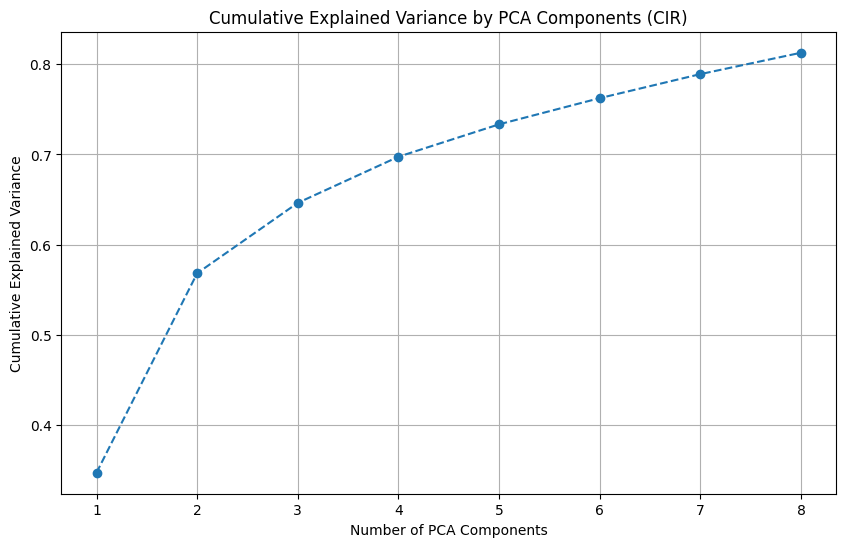

In [13]:
# GOAL:
#   Plot the cumulative explained variance of the 10 principal components
#   to visualize how quickly the variance is captured.

# WHY:
#   A scree plot helps confirm whether 10 components are sufficient
#   or if we should consider more. It's a visual way to see if
#   additional PCs beyond 10 add significant variance.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 9), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components (CIR)')
plt.xticks(range(1,9))
plt.grid(True)
plt.show()

# Reason:
#   If the plot shows a plateau near 10 components, it validates our choice.
#   If the curve is still steep at 10, we might consider increasing n_components.


Cell 12: Correlation Checks (Core Features vs. NLOS & RANGE)

In [14]:
# GOAL:
#   Compute the correlation of each core feature with NLOS (0/1) and RANGE,
#   to see how strongly each feature is associated with the classification
#   and regression targets.

# WHY:
#   A higher absolute correlation suggests a stronger linear relationship.
#   This helps decide which features might be relevant.

# Reason:
#   Features with near-zero correlation to both NLOS and RANGE are often
#   prime candidates for removal, unless domain knowledge says otherwise.

# 1. Convert NLOS to numeric if needed (assuming it's already 0 or 1)
#    If it's a string or category, do: uwb_df["NLOS"] = uwb_df["NLOS"].map({"LOS":0, "NLOS":1})

core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", 
    "MAX_NOISE", "RXPACC", "FRAME_LEN", "PREAM_LEN"
    # Adjust if you have a different final set
]

# 2. Correlation with NLOS
corr_nlos = uwb_df[core_features + ["NLOS"]].corr()
print("Correlation with NLOS:\n", corr_nlos["NLOS"])

# 3. Correlation with RANGE
corr_range = uwb_df[core_features + ["RANGE"]].corr()
print("\nCorrelation with RANGE:\n", corr_range["RANGE"])


Correlation with NLOS:
 FP_IDX      -0.316978
FP_AMP1     -0.447279
FP_AMP2     -0.524905
CIR_PWR     -0.392303
MAX_NOISE   -0.198198
RXPACC       0.730690
FRAME_LEN    0.034316
PREAM_LEN    0.189658
NLOS         1.000000
Name: NLOS, dtype: float64

Correlation with RANGE:
 FP_IDX      -0.321809
FP_AMP1     -0.459196
FP_AMP2     -0.479689
CIR_PWR     -0.263718
MAX_NOISE   -0.260065
RXPACC       0.626349
FRAME_LEN   -0.048082
PREAM_LEN    0.390055
RANGE        1.000000
Name: RANGE, dtype: float64


Cell 13: Random Forest Feature Importance (Classification: NLOS)

In [ ]:
# GOAL:
#   Train a quick RandomForestClassifier on the core features to see
#   which features are most important for classifying NLOS vs. LOS.

# WHY:
#   Feature importance reveals non-linear relationships that correlation might miss.
#   Higher importance means a feature significantly aids classification.

# Reason:
#   If a feature has near-zero importance, you can safely remove it.

from sklearn.ensemble import RandomForestClassifier

# 1. Prepare data for classification
X_class = uwb_df[core_features].values
y_class = uwb_df["NLOS"].values  # 0 or 1

# 2. Fit a random forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_class, y_class)

# 3. Print feature importances
importances_clf = rf_clf.feature_importances_
for feat, imp in zip(core_features, importances_clf):
    print(f"{feat} importance (NLOS classification): {imp:.5f}")


Cell 14: Random Forest Feature Importance (Regression: RANGE)

In [ ]:
# GOAL:
#   Train a quick RandomForestRegressor on the core features to see
#   which features help predict RANGE.

# WHY:
#   Some features might be relevant for classification but not for regression, or vice versa.

# Reason:
#   If a feature is unimportant for both classification and regression,
#   it's a strong candidate for removal.

from sklearn.ensemble import RandomForestRegressor

# 1. Prepare data for regression
X_reg = uwb_df[core_features].values
y_reg = uwb_df["RANGE"].values

# 2. Fit a random forest regressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_reg, y_reg)

# 3. Print feature importances
importances_reg = rf_reg.feature_importances_
for feat, imp in zip(core_features, importances_reg):
    print(f"{feat} importance (RANGE regression): {imp:.5f}")


Cell 15: Merged the 15 features results and saved inside prepared directory.

In [15]:
# GOAL:
#   Merge the 8-component PCA result (already computed in cir_pca) with the final core features
#   and the labels (NLOS, RANGE) into one DataFrame for classification/regression.

# WHY:
#   Having performed partial PCA on the CIR data, we want to integrate the reduced CIR features
#   (CIR_PC1..CIR_PC8) with our domain-relevant core features, excluding FRAME_LEN, and
#   include the target variables. This final DataFrame is what we'll use for modeling.

# Reason:
#   This step finalizes the partial PCA approach. We end up with a lean set of features:
#   1) pruned core features (minus FRAME_LEN),
#   2) 8 principal components for the CIR data,
#   3) labels for classification (NLOS) and regression (RANGE).

import pandas as pd

# 1. Define the final core features (excluding FRAME_LEN)
final_core_features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", 
    "CIR_PWR", "MAX_NOISE", "RXPACC", 
    "PREAM_LEN", "STDEV_NOISE", "FP_AMP3" # e.g., if you decided to keep PREAM_LEN
]

# 2. Create a DataFrame for the PCA-transformed CIR columns (8 PCs)
cir_pc_cols = [f"CIR_PC{i+1}" for i in range(8)]
df_cir_pca = pd.DataFrame(cir_pca, columns=cir_pc_cols)

# 3. Concatenate final_core_features, the 8 PCA columns, and labels
#    Assuming you have uwb_df with the full dataset, including NLOS, RANGE
label_cols = ["NLOS", "RANGE"]

final_df = pd.concat([
    uwb_df[final_core_features].reset_index(drop=True),
    df_cir_pca.reset_index(drop=True),
    uwb_df[label_cols].reset_index(drop=True)
], axis=1)

print("Final DataFrame shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())
final_df.head()

# (Optional) Save the final preprocessed dataset
save_path = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
final_df.to_csv(save_path, index=False)
print(f"Final preprocessed data saved to: {save_path}")


Final DataFrame shape: (42000, 19)
Columns: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'STDEV_NOISE', 'FP_AMP3', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'CIR_PC7', 'CIR_PC8', 'NLOS', 'RANGE']
Final preprocessed data saved to: ../dataset/prepared/final_preprocessed_8PCs_both_all.csv


Cell 16: Visualisation

In [ ]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure that final_core_features, cir_pc_cols, and final_df are defined.
# If they aren't defined in previous cells, we'll define/load them here.

try:
    final_core_features
except NameError:
    # Define final_core_features (excluding FRAME_LEN as per our decision)
    final_core_features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", "MAX_NOISE", "RXPACC", "PREAM_LEN"]
    print("final_core_features not defined. Defined as:", final_core_features)

try:
    cir_pc_cols
except NameError:
    # Define cir_pc_cols assuming 8 PCA components
    cir_pc_cols = [f"CIR_PC{i+1}" for i in range(8)]
    print("cir_pc_cols not defined. Defined as:", cir_pc_cols)

try:
    final_df
except NameError:
    # If final_df isn't defined, load it from the saved CSV file.
    # Adjust the path as needed.
    final_df = pd.read_csv("../dataset/UWB-LOS-NLOS-Data-Set/prepared/final_preprocessed_8PCs.csv")
    print("final_df not defined. Loaded final_df from CSV.")

# =========================
# Visualize the Final Preprocessed Dataset
# =========================

# ---------- Part A: Correlation Heatmap for Final Features (excluding labels) ----------
# GOAL:
#   Examine the pairwise correlations among the final core features and the 8 PCA components.
#
# WHY:
#   High correlation may indicate redundancy. This helps confirm that our features
#   are sufficiently diverse for modeling.
#
# Reason:
#   We want to ensure that our final feature set (core features + CIR PCs) has meaningful differences.
features_for_heatmap = final_core_features + cir_pc_cols

plt.figure(figsize=(12, 10))
corr_final = final_df[features_for_heatmap].corr()
sns.heatmap(corr_final, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: Core Features + 8 CIR PCs")
plt.show()

# ---------- Part B: Scatter Plot of the First Two PCA Components ----------
# GOAL:
#   Visualize the first two principal components from the CIR PCA.
#
# WHY:
#   To assess whether the PCA-transformed CIR data separates the classes (LOS vs. NLOS).
#
# Reason:
#   A clear separation in the scatter plot indicates that PCA effectively captures relevant variance.
plt.figure(figsize=(8,6))
plt.scatter(final_df["CIR_PC1"], final_df["CIR_PC2"], c=final_df["NLOS"], cmap="viridis", alpha=0.6)
plt.xlabel("CIR_PC1")
plt.ylabel("CIR_PC2")
plt.title("Scatter Plot of First Two CIR PCA Components (Color-coded by NLOS)")
plt.colorbar(label="NLOS (0: LOS, 1: NLOS)")
plt.grid(True)
plt.show()

# ---------- Part C: Direct Comparison with Color Coding ----------
# GOAL:
#   Compare the distribution of two original core features (FP_AMP1 vs FP_AMP2)
#   in the original feature space, color-coded by NLOS.

# WHY:
#   Coloring by NLOS reveals if there's any visual separation or pattern in how
#   FP_AMP1 and FP_AMP2 differ for LOS vs. NLOS classes.

# Reason:
#   If these features provide some class separation, we might see distinct color clusters.

plt.figure(figsize=(8,6))
plt.scatter(
    final_df["FP_AMP1"], 
    final_df["FP_AMP2"], 
    c=final_df["NLOS"],    # color by the NLOS label
    cmap="viridis",        # color map
    alpha=0.5
)
plt.xlabel("FP_AMP1")
plt.ylabel("FP_AMP2")
plt.title("Scatter Plot of FP_AMP1 vs FP_AMP2 (Color-coded by NLOS)")
plt.colorbar(label="NLOS (0: LOS, 1: NLOS)")
plt.grid(True)
plt.show()



PCA Scatter Plot (CIR_PC1 vs. CIR_PC2):
Shows the first two principal components of the normalized CIR data, colored by NLOS (0=LOS in yellow, 1=NLOS in purple). While some clustering is visible, there’s still overlap, indicating these two PCs alone don’t completely separate LOS from NLOS.

Amplitude Scatter Plot (FP_AMP1 vs. FP_AMP2):
Plots the raw amplitude features FP_AMP1 (x-axis) and FP_AMP2 (y-axis), also colored by NLOS. The distribution forms a broad rectangular shape with significant overlap between LOS (yellow) and NLOS (purple), suggesting these two amplitude features alone aren’t sufficient for clear class separation.

In [ ]:
import os
import pandas as pd
import numpy as np

# =========================
# Load Final Preprocessed Dataset & Clean It
# =========================

# GOAL:
#   1. Load the final preprocessed CSV from the 'prepared' directory.
#   2. Check and handle missing values.
#   3. Remove duplicates and erroneous entries.

# WHY:
#   Data cleaning is crucial for reliable modeling. 
#   The final preprocessed dataset might still have missing or invalid rows.

# Reason:
#   Ensures consistent, valid data for classification/regression tasks.

# 1. Load the final preprocessed dataset from 'prepared' directory
try:
    final_df = pd.read_csv("../dataset/prepared/final_preprocessed_8PCs.csv")
    print("Loaded final_df from final_preprocessed_8PCs.csv.")
except FileNotFoundError:
    print("Error: The CSV file was not found. Please check the path.")
except Exception as e:
    print(f"Error loading final_df: {e}")

# 2. Check for missing values
missing_counts = final_df.isnull().sum()
print("Missing value counts:\n", missing_counts)

# Example approach:
# - If minimal missing values, drop rows or columns with missing data
# - If significant, use imputation (mean, median, etc.)
final_df.dropna(axis=0, how="any", inplace=True)
print("Dropped rows with missing values. Current shape:", final_df.shape)

# 3. Check for duplicates
duplicates = final_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    final_df.drop_duplicates(inplace=True)
    print("Duplicates removed. Current shape:", final_df.shape)

# 4. Remove erroneous entries
# Example: negative range or negative amplitude
# Adjust these thresholds as per domain knowledge
before_count = len(final_df)
final_df = final_df[
    (final_df["RANGE"] >= 0) &
    (final_df["FP_AMP1"] >= 0) & 
    (final_df["FP_AMP2"] >= 0)
]
after_count = len(final_df)
print(f"Removed {before_count - after_count} rows with negative or impossible values.")
print("Final shape after cleaning:", final_df.shape)

# Optional: preview the cleaned DataFrame
final_df.head()


In [ ]:
# GOAL:
#   Discard NLOS samples from the dataset, keeping only LOS samples for range regression.
#
# WHY:
#   LOS samples are more reliable for distance estimation; NLOS measurements introduce large errors.
#
# Reason:
#   The assignment indicates that for range estimation, only LOS data should be used.
#   Here, we filter the final DataFrame to keep rows where NLOS == 0.

# Filter the final DataFrame to keep only LOS samples
los_df = final_df[final_df["NLOS"] == 0].copy()

print("Remaining rows after discarding NLOS samples:", los_df.shape[0])
los_df.head()


In [9]:
# GOAL:
#   Remove the NLOS column from the dataset (since only LOS samples are retained)
#   and overwrite the final preprocessed CSV file.
#
# WHY:
#   The NLOS feature is no longer needed for range regression because we've already
#   filtered to keep only LOS samples.
#
# Reason:
#   Dropping this column simplifies the dataset for regression modeling and avoids
#   potential confusion downstream.

# Check if "NLOS" is present in the DataFrame before dropping it.
if "NLOS" in los_df.columns:
    los_df = los_df.drop(columns=["NLOS"])
    print("Dropped 'NLOS' column. Remaining columns:", los_df.columns.tolist())
else:
    print("'NLOS' column not found. Skipping drop.")

# Save the updated LOS-only dataset to the prepared directory (overwriting the file)
save_path = "../dataset/prepared/final_preprocessed_8PCs_all.csv"
los_df.to_csv(save_path, index=False)
print(f"Final LOS-only preprocessed data saved to: {save_path}")


NameError: name 'los_df' is not defined

Loaded final_df from ../dataset/prepared/final_preprocessed_8PCs.csv. Shape: (21000, 16)

Correlation with RANGE (sorted by absolute value):
      Feature  Correlation  AbsoluteCorr  Rank
0     CIR_PC1    -0.668823      0.668823     1
1      RXPACC     0.610908      0.610908     2
2   MAX_NOISE    -0.422511      0.422511     3
3     FP_AMP1    -0.316904      0.316904     4
4     FP_AMP2    -0.182580      0.182580     5
5     CIR_PC4    -0.140052      0.140052     6
6   PREAM_LEN     0.102192      0.102192     7
7     CIR_PC2    -0.082019      0.082019     8
8     CIR_PC5     0.060792      0.060792     9
9     CIR_PC3    -0.048555      0.048555    10
10    CIR_PC6     0.046584      0.046584    11
11     FP_IDX    -0.045120      0.045120    12
12    CIR_PC8     0.036625      0.036625    13
13    CIR_PWR    -0.035664      0.035664    14
14    CIR_PC7     0.030486      0.030486    15


C:\Users\wmjia\AppData\Local\Temp\ipykernel_44660\2309038777.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Feature", y="Correlation", data=corr_ranking_df, palette="viridis")


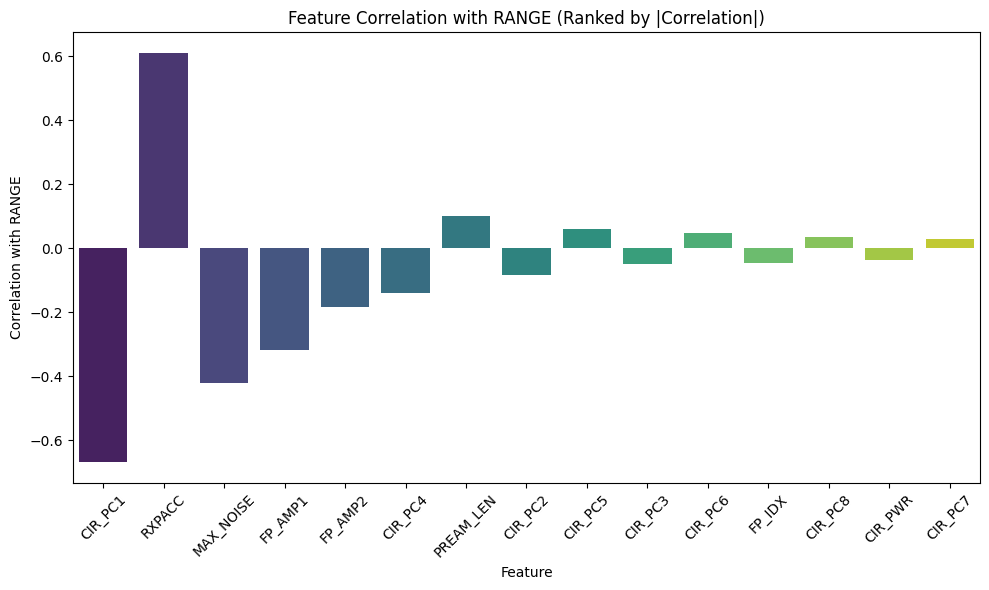


Tree-based Feature Importances (Random Forest):
      Feature  Importance
5      RXPACC    0.402818
7     CIR_PC1    0.125200
3     CIR_PWR    0.108941
4   MAX_NOISE    0.060284
9     CIR_PC3    0.040431
2     FP_AMP2    0.040382
10    CIR_PC4    0.037412
1     FP_AMP1    0.036270
11    CIR_PC5    0.029814
14    CIR_PC8    0.027342
12    CIR_PC6    0.027338
13    CIR_PC7    0.027192
8     CIR_PC2    0.027176
0      FP_IDX    0.008928
6   PREAM_LEN    0.000475


C:\Users\wmjia\AppData\Local\Temp\ipykernel_44660\2309038777.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="plasma")


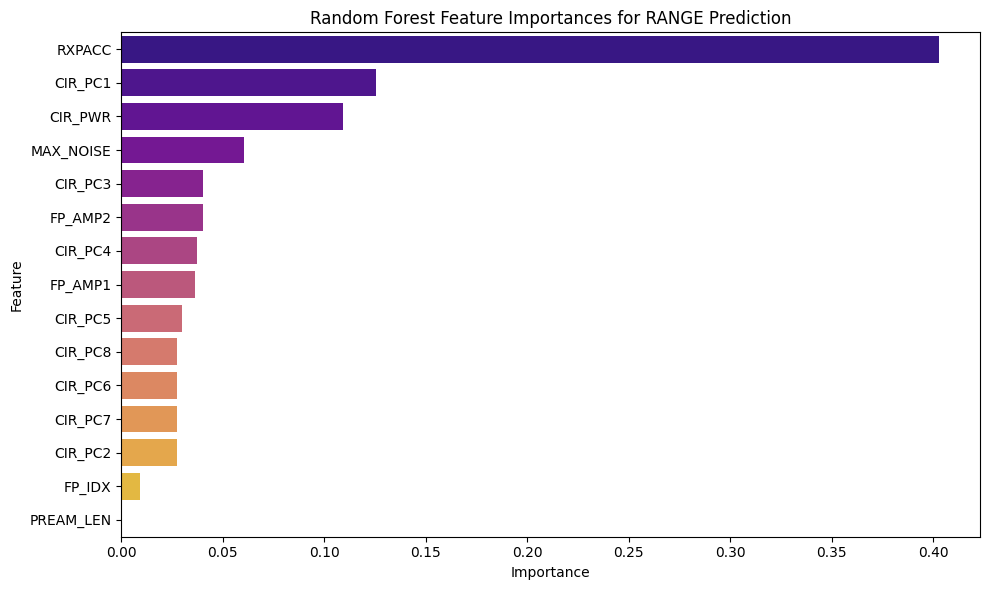

In [27]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# =========================
# Load Final Preprocessed Data & Evaluate Feature Importance
# =========================

# GOAL:
#   1. Load final preprocessed data (final_preprocessed_8PCs.csv) from the 'prepared' directory.
#   2. Evaluate feature importance via correlation ranking and RandomForestRegressor.

# WHY:
#   Ensuring the dataset is loaded first avoids NameErrors or missing data issues.
#   Feature importance helps identify which features matter most for RANGE prediction.

# Reason:
#   This consolidated cell keeps the workflow straightforward and ensures no analysis occurs 
#   before the dataset is confirmed to be loaded.

# 1. Load final_df from 'prepared' directory
prepared_file_path = "../dataset/prepared/final_preprocessed_8PCs.csv"
try:
    final_df = pd.read_csv(prepared_file_path)
    print(f"Loaded final_df from {prepared_file_path}. Shape: {final_df.shape}")
except FileNotFoundError:
    print(f"Error: Could not find {prepared_file_path}. Please ensure the file exists.")
except Exception as e:
    print(f"Error loading final_df: {e}")

# 2. Ensure cir_pc_cols is defined (assuming 8 PCA components)
try:
    cir_pc_cols
except NameError:
    cir_pc_cols = [f"CIR_PC{i+1}" for i in range(8)]
    print("cir_pc_cols not defined. Defined as:", cir_pc_cols)

# 3. Define the features (7 core + 8 PCA)
feature_cols = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", 
    "CIR_PWR", "MAX_NOISE", "RXPACC", 
    "PREAM_LEN"
] + cir_pc_cols

# 4. Check that RANGE is in final_df
if "RANGE" not in final_df.columns:
    print("Warning: 'RANGE' column not found in final_df.")
else:
    # --- Part A: Correlation Analysis ---
    # Compute correlation of each feature with RANGE (excluding the target itself)
    corr_series = final_df[feature_cols + ["RANGE"]].corr()["RANGE"].drop("RANGE")

    # Sort correlation by absolute value (descending)
    corr_sorted = corr_series.abs().sort_values(ascending=False)

    # Create a DataFrame to show correlation ranking
    corr_ranking_df = pd.DataFrame({
        "Feature": corr_sorted.index,
        "Correlation": corr_series[corr_sorted.index].values,  # signed correlation
        "AbsoluteCorr": corr_sorted.values,
        "Rank": np.arange(1, len(corr_sorted)+1)
    })

    print("\nCorrelation with RANGE (sorted by absolute value):")
    print(corr_ranking_df)

    # Bar plot for correlation (signed) in descending order of absolute correlation
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Feature", y="Correlation", data=corr_ranking_df, palette="viridis")
    plt.xticks(rotation=45)
    plt.ylabel("Correlation with RANGE")
    plt.title("Feature Correlation with RANGE (Ranked by |Correlation|)")
    plt.tight_layout()
    plt.show()

    # --- Part B: Tree-based Feature Importance (RandomForestRegressor) ---
    # Prepare the features and target variable for regression
    X = final_df[feature_cols]
    y = final_df["RANGE"]

    # Create and train a RandomForestRegressor
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)

    # Extract feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nTree-based Feature Importances (Random Forest):")
    print(feature_importance_df)

    # Visualize the feature importances
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="plasma")
    plt.title("Random Forest Feature Importances for RANGE Prediction")
    plt.tight_layout()
    plt.show()


Standardized Linear Regression Coefficients:
      Feature  Coefficient  AbsoluteCoefficient
7     CIR_PC1    -0.990660             0.990660
8     CIR_PC2    -0.287389             0.287389
9     CIR_PC3     0.217604             0.217604
1     FP_AMP1    -0.189534             0.189534
0      FP_IDX    -0.132230             0.132230
5      RXPACC     0.128393             0.128393
10    CIR_PC4    -0.104159             0.104159
12    CIR_PC6     0.075302             0.075302
14    CIR_PC8     0.068866             0.068866
6   PREAM_LEN     0.053841             0.053841
3     CIR_PWR     0.033562             0.033562
4   MAX_NOISE    -0.020017             0.020017
13    CIR_PC7     0.009128             0.009128
2     FP_AMP2     0.001001             0.001001
11    CIR_PC5    -0.000229             0.000229


C:\Users\wmjia\AppData\Local\Temp\ipykernel_44660\852598909.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AbsoluteCoefficient", y="Feature", data=coef_df, palette="coolwarm")


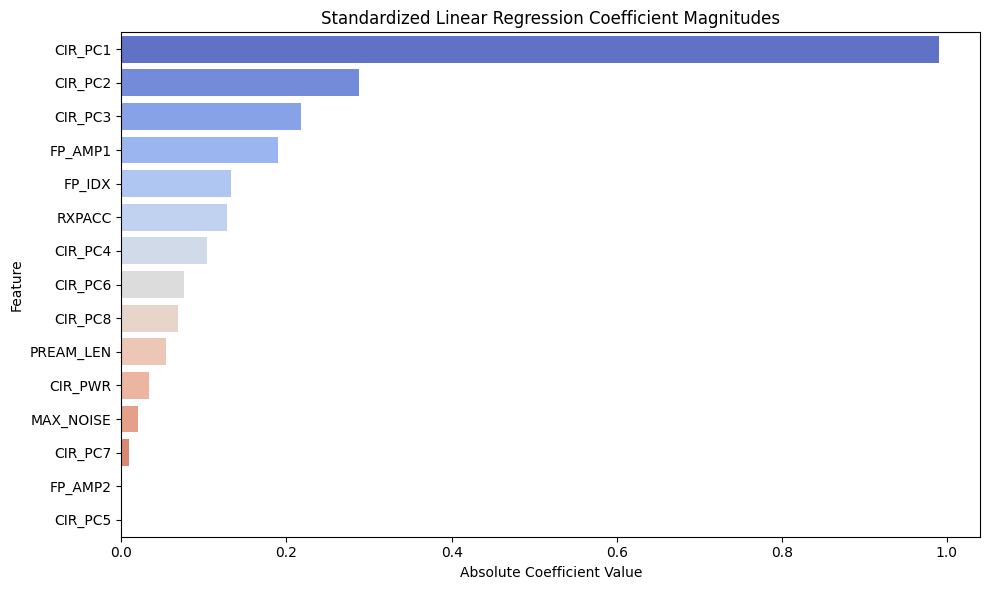

LASSO Regression Coefficients:
      Feature  Coefficient  AbsoluteCoefficient
7     CIR_PC1    -0.934642             0.934642
8     CIR_PC2    -0.230918             0.230918
1     FP_AMP1    -0.185929             0.185929
9     CIR_PC3     0.181553             0.181553
5      RXPACC     0.175601             0.175601
10    CIR_PC4    -0.098427             0.098427
0      FP_IDX    -0.079975             0.079975
12    CIR_PC6     0.062306             0.062306
14    CIR_PC8     0.056931             0.056931
6   PREAM_LEN     0.042667             0.042667
4   MAX_NOISE    -0.025863             0.025863
3     CIR_PWR     0.009463             0.009463
2     FP_AMP2    -0.003720             0.003720
13    CIR_PC7     0.003155             0.003155
11    CIR_PC5     0.000000             0.000000


C:\Users\wmjia\AppData\Local\Temp\ipykernel_44660\852598909.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AbsoluteCoefficient", y="Feature", data=lasso_df, palette="viridis")


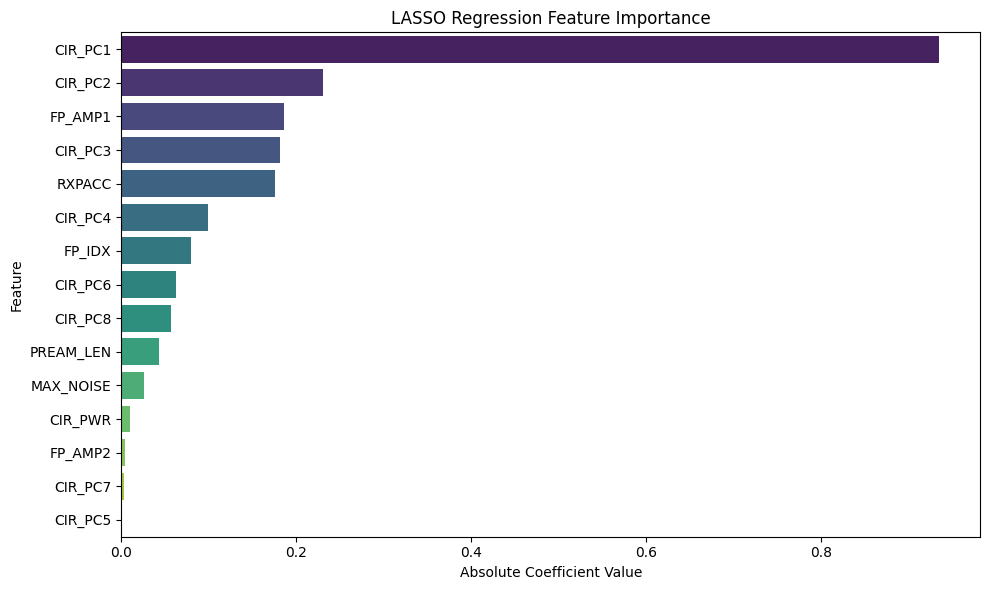

In [33]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler

# --- Linear Regression Feature Importance ---

# GOAL:
#   Assess feature importance using a linear regression model by examining
#   the standardized coefficients.
#
# WHY:
#   Standardizing the features allows direct comparison of coefficients
#   in a linear model. Features with larger absolute coefficients are more important.
#
# Reason:
#   This helps identify which features are most linearly predictive of RANGE.

# Standardize features
scaler_lin = StandardScaler()
X_scaled = scaler_lin.fit_transform(final_df[feature_cols])
y = final_df["RANGE"]

# Fit Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

# Retrieve coefficients
coefficients = lin_reg.coef_

# Create a DataFrame for visualization and ranking
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coefficients,
    "AbsoluteCoefficient": np.abs(coefficients)
}).sort_values("AbsoluteCoefficient", ascending=False)

print("Standardized Linear Regression Coefficients:")
print(coef_df)

plt.figure(figsize=(10,6))
sns.barplot(x="AbsoluteCoefficient", y="Feature", data=coef_df, palette="coolwarm")
plt.title("Standardized Linear Regression Coefficient Magnitudes")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- LASSO Regression Feature Importance ---
# GOAL:
#   Use LASSO regression to assess feature importance while performing feature selection.
#
# WHY:
#   LASSO adds L1 regularization, which can drive some coefficients to zero if they're not useful,
#   effectively selecting important features.
#
# Reason:
#   This provides a robust method for evaluating which features contribute most to the model.
lasso = Lasso(alpha=0.01, random_state=42)  # Adjust alpha as needed
lasso.fit(X_scaled, y)
lasso_coefs = lasso.coef_

lasso_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso_coefs,
    "AbsoluteCoefficient": np.abs(lasso_coefs)
}).sort_values("AbsoluteCoefficient", ascending=False)

print("LASSO Regression Coefficients:")
print(lasso_df)

plt.figure(figsize=(10,6))
sns.barplot(x="AbsoluteCoefficient", y="Feature", data=lasso_df, palette="viridis")
plt.title("LASSO Regression Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


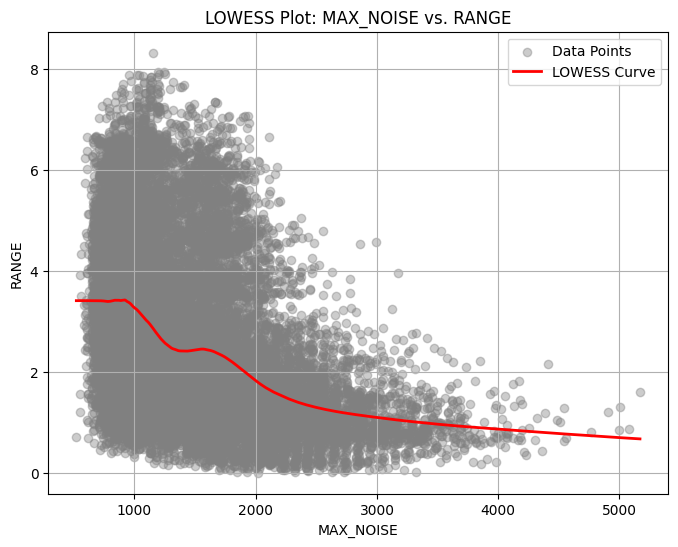

In [42]:
import statsmodels.api as sm

# =========================
# Cell 3: Nonparametric Smoothing (LOWESS)
# =========================

# GOAL:
#   Plot the feature vs. RANGE with a LOWESS curve to see if the relationship
#   deviates from a straight line.

# WHY:
#   If LOWESS significantly curves away from a linear fit, that indicates nonlinearity.

# Reason:
#   Visual approach to confirm whether a linear assumption holds.

feature_for_lowess = "MAX_NOISE"  # Example: pick another feature
if feature_for_lowess not in final_df.columns:
    print(f"Feature {feature_for_lowess} not found in final_df.")
else:
    x_lowess = final_df[feature_for_lowess].values
    y_lowess = final_df["RANGE"].values

    # Perform LOWESS smoothing
    lowess_result = sm.nonparametric.lowess(endog=y_lowess, exog=x_lowess, frac=0.2) 
    # frac is the smoothing parameter; adjust as needed

    # Convert to arrays for plotting
    x_smoothed = lowess_result[:, 0]
    y_smoothed = lowess_result[:, 1]

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(x_lowess, y_lowess, alpha=0.4, color="gray", label="Data Points")
    plt.plot(x_smoothed, y_smoothed, color="red", linewidth=2, label="LOWESS Curve")
    plt.xlabel(feature_for_lowess)
    plt.ylabel("RANGE")
    plt.title(f"LOWESS Plot: {feature_for_lowess} vs. RANGE")
    plt.legend()
    plt.grid(True)
    plt.show()


Loaded final_df from ../dataset/prepared/final_preprocessed_8PCs.csv. Shape: (21000, 16)


c:\Users\wmjia\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


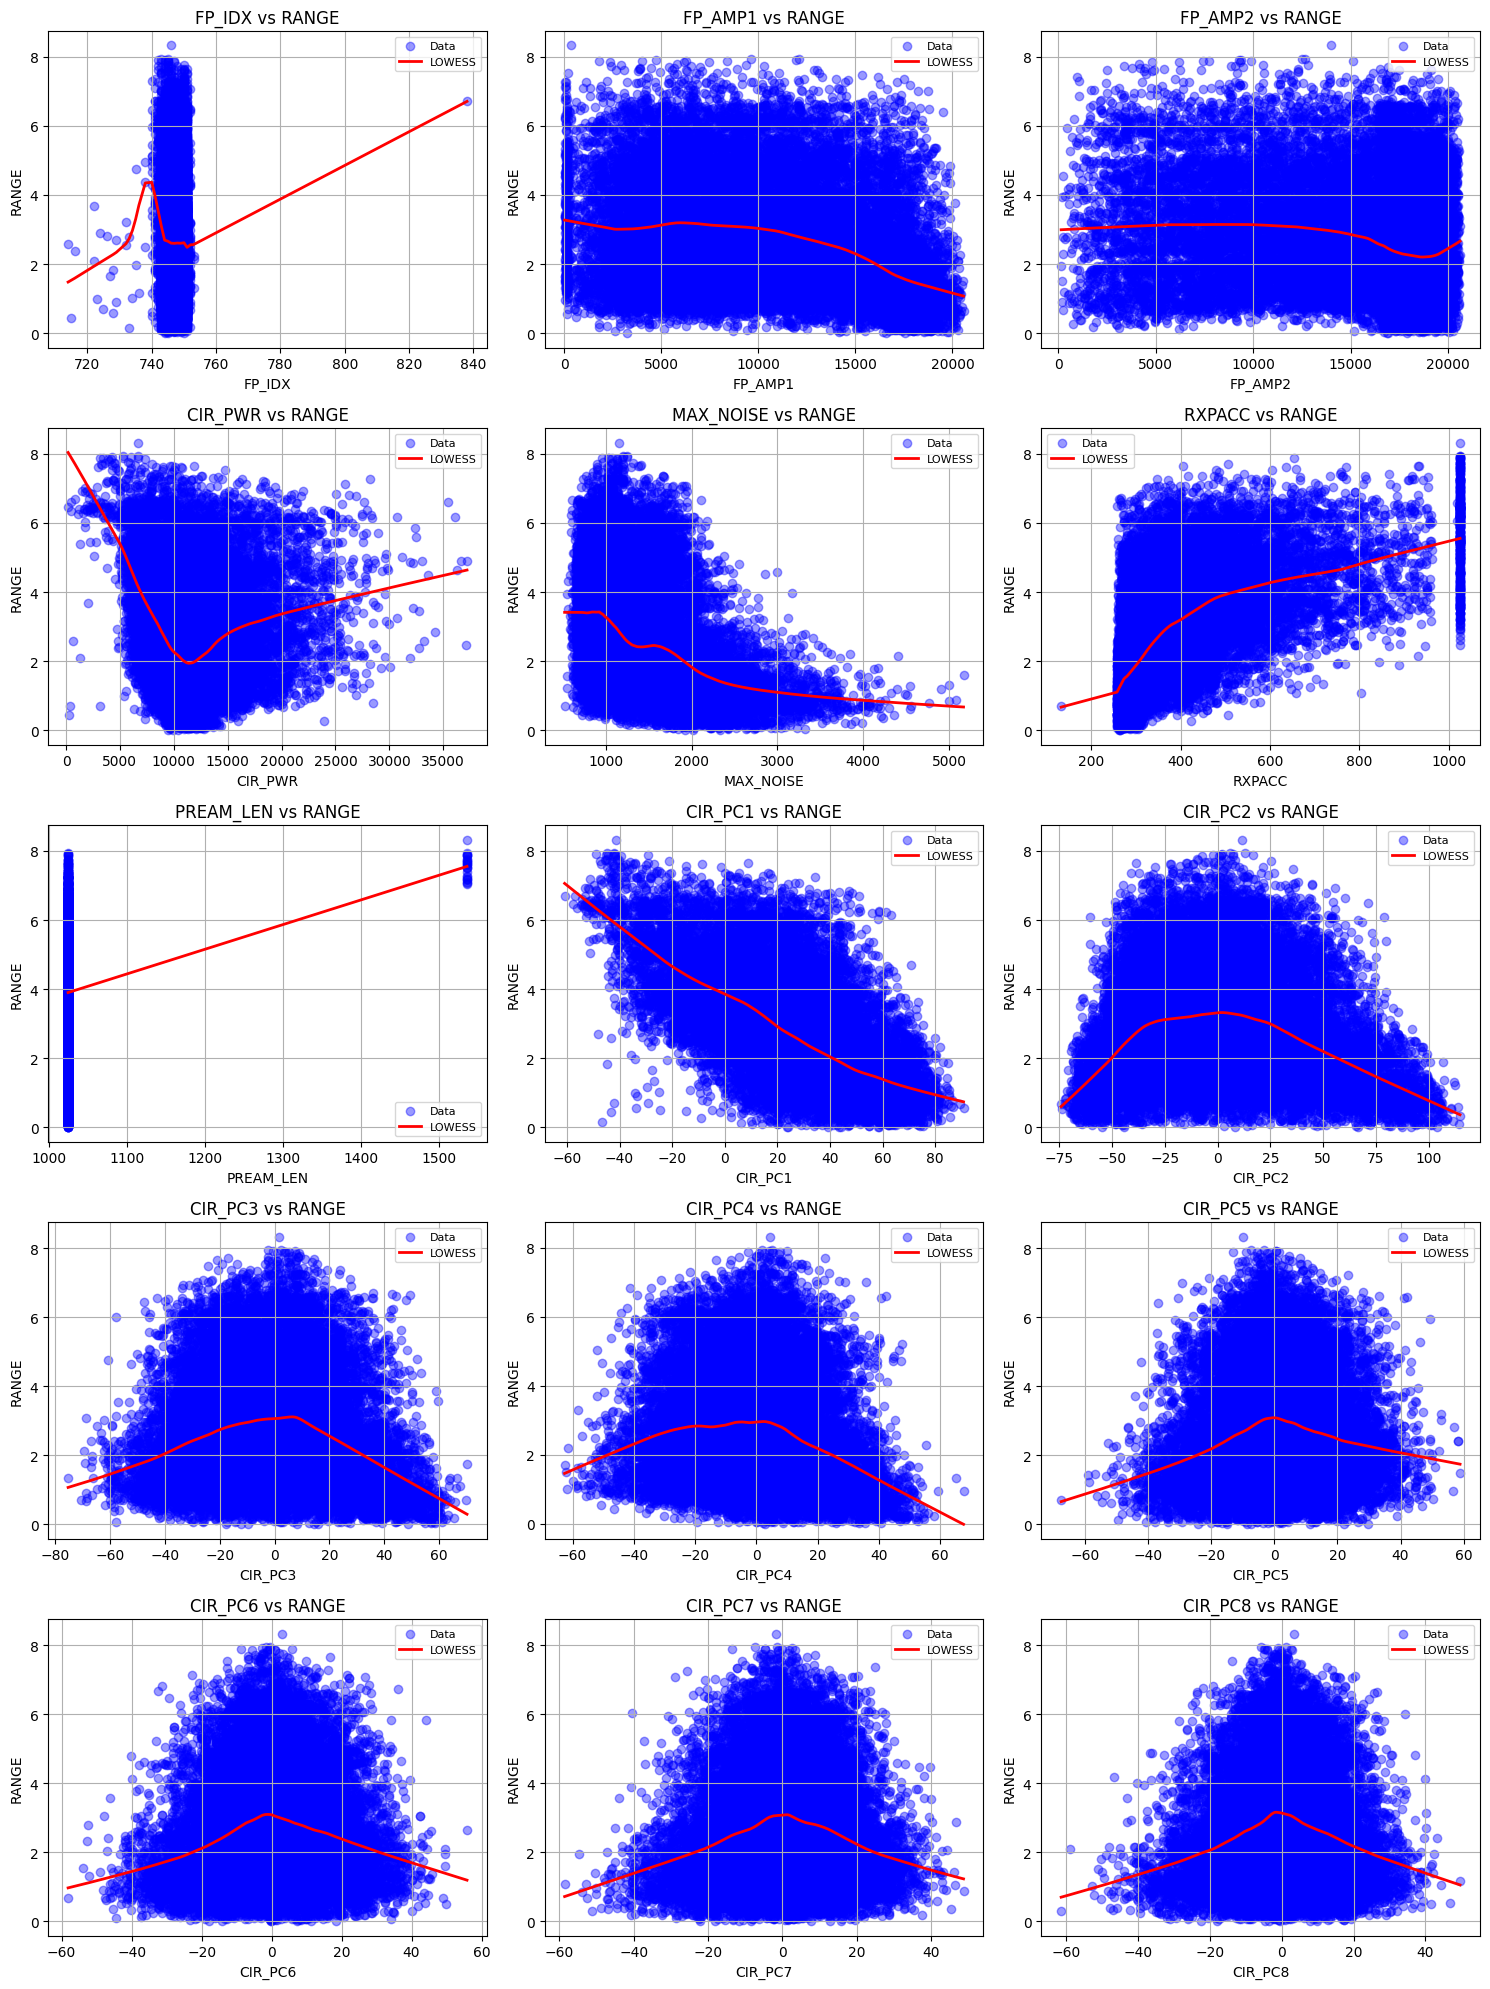

In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# =========================
# Unified Cell: Assess Linearity for All Features vs. RANGE
# =========================

# GOAL:
#   Load the final preprocessed dataset from the prepared directory,
#   then for each selected feature (core features + PCA components), create:
#     - A scatter plot with LOWESS smoothing to visualize the feature vs. RANGE relationship.
#     - For a couple of selected features, also produce residual plots from a linear regression.
#
# WHY:
#   Visual diagnostics (scatter plots, LOWESS curves, residual plots) help determine whether the relationship
#   between a feature and the target is linear. If the LOWESS curve and residuals suggest curvature or systematic
#   patterns, the relationship may be nonlinear.
#
# Reason:
#   This analysis guides whether a simple linear model is sufficient or if a nonlinear model should be considered.

# 1. Load the final preprocessed dataset from the prepared directory.
prepared_path = "../dataset/prepared/final_preprocessed_8PCs.csv"

try:
    final_df = pd.read_csv(prepared_path)
    print(f"Loaded final_df from {prepared_path}. Shape: {final_df.shape}")
except Exception as e:
    print(f"Error loading final_df: {e}")

# 2. Ensure cir_pc_cols is defined (assuming 8 PCA components)
try:
    cir_pc_cols
except NameError:
    cir_pc_cols = [f"CIR_PC{i+1}" for i in range(8)]
    print("cir_pc_cols not defined. Defined as:", cir_pc_cols)

# 3. Define the list of features to check (core features + PCA components)
feature_cols = ["FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", "MAX_NOISE", "RXPACC", "PREAM_LEN"] + cir_pc_cols
target = "RANGE"

# -------------------------
# Part A: Scatter Plots with LOWESS for All Features
# -------------------------
n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(5*n_cols, 4*n_rows))
for i, feat in enumerate(feature_cols, start=1):
    if feat not in final_df.columns:
        print(f"Feature {feat} not found in final_df; skipping.")
        continue
    x = final_df[feat].values
    y = final_df[target].values
    
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(x, y, alpha=0.4, color="blue", label="Data")
    plt.xlabel(feat)
    plt.ylabel(target)
    plt.title(f"{feat} vs {target}")
    
    # LOWESS smoothing to check for nonlinearity
    try:
        import statsmodels.api as sm
        lowess_result = sm.nonparametric.lowess(endog=y, exog=x, frac=0.2)
        lowess_result = lowess_result[np.argsort(lowess_result[:, 0])]  # sort for plotting
        plt.plot(lowess_result[:, 0], lowess_result[:, 1], color="red", linewidth=2, label="LOWESS")
    except ImportError:
        print("statsmodels not installed; skipping LOWESS for", feat)
    
    plt.legend(fontsize=8)
    plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split

# =========================
# Cell: Train/Test Split for LOS Regression and Save
# =========================

# GOAL:
#   Split the LOS-only dataset into training (70%) and testing (30%) sets,
#   then save these sets to the prepared directory.
#
# WHY:
#   A 70:30 split offers sufficient data for model training while retaining an unbiased
#   evaluation set. Saving them ensures reproducibility and easier access for further processing.
#
# Reason:
#   This split minimizes the risk of overfitting and allows consistent indexing when re-running experiments.

# Define features and target (assuming los_df is already defined from previous steps)
features = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", "MAX_NOISE", "RXPACC", "PREAM_LEN"
] + [f"CIR_PC{i+1}" for i in range(8)]
target = "RANGE"

# Separate the features (X) and target (y)
X = los_df[features]
y = los_df[target]

# Perform a 70:30 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

# Create DataFrames for the training and testing sets (including the target)
train_df = X_train.copy()
train_df[target] = y_train
test_df = X_test.copy()
test_df[target] = y_test

# Save the training and testing sets to the prepared directory
train_save_path = "../dataset/prepared/los_train.csv"
test_save_path = "../dataset/prepared/los_test.csv"

train_df.to_csv(train_save_path, index=False)
test_df.to_csv(test_save_path, index=False)

print(f"Training set saved to: {train_save_path}")
print(f"Testing set saved to: {test_save_path}")


Training set shape: (14700, 15), Testing set shape: (6300, 15)
Training set saved to: ../dataset/prepared/los_train.csv
Testing set saved to: ../dataset/prepared/los_test.csv


In [56]:
import os
import pandas as pd
import numpy as np

# =========================
# Unified Verification Cell: Row-by-Row Consistency & Summary Statistics
# =========================

# GOAL:
#   1. Load the full final_preprocessed_8PCs.csv from the prepared directory.
#   2. Filter to retain only LOS samples.
#   3. Load the train and test splits (los_train.csv, los_test.csv).
#   4. Check row-level consistency using row fingerprints, ensure no overlap between train and test,
#      and verify that the combined train/test set matches the original LOS data.
#   5. Print summary statistics (describe) for the original, training, and test datasets.
#
# WHY:
#   These steps ensure that your data splitting is correct, no data is lost or duplicated,
#   and that the statistical distribution of features remains consistent across subsets.
#
# Reason:
#   Validating data integrity at this stage prevents errors later in modeling.

# 1. Load the full final_preprocessed_8PCs.csv
final_pre_path = "../dataset/prepared/final_preprocessed_8PCs.csv"
try:
    full_df = pd.read_csv(final_pre_path)
    print(f"Loaded final_preprocessed_8PCs.csv from {final_pre_path}. Shape: {full_df.shape}")
except Exception as e:
    print(f"Error loading {final_pre_path}: {e}")
    full_df = pd.DataFrame()

# 2. Filter out NLOS rows to obtain the original LOS data.
if not full_df.empty and "NLOS" in full_df.columns:
    los_df_original = full_df[full_df["NLOS"] == 0].copy()
    print(f"LOS-only subset shape from final_preprocessed_8PCs.csv: {los_df_original.shape}")
else:
    print("Warning: 'NLOS' column not found or file is empty. Assuming the file is already LOS-only.")
    los_df_original = full_df

# 3. Load the train and test splits
train_path = "../dataset/prepared/los_train.csv"
test_path = "../dataset/prepared/los_test.csv"
try:
    los_train = pd.read_csv(train_path)
    los_test = pd.read_csv(test_path)
    print(f"\nLoaded train set from {train_path}. Shape: {los_train.shape}")
    print(f"Loaded test set from {test_path}. Shape: {los_test.shape}")
except Exception as e:
    print(f"Error loading train/test sets: {e}")
    los_train = pd.DataFrame()
    los_test = pd.DataFrame()

# 4. Create row "fingerprints" for each DataFrame to check for consistency
def make_fingerprints(df):
    """
    Convert each row to a string fingerprint based on sorted column values.
    """
    sorted_cols = sorted(df.columns)
    return set(df[sorted_cols].astype(str).apply(lambda row: "_".join(row.values), axis=1))

if not los_df_original.empty and not los_train.empty and not los_test.empty:
    orig_fps = make_fingerprints(los_df_original)
    train_fps = make_fingerprints(los_train)
    test_fps = make_fingerprints(los_test)

    # Check if all train rows exist in the original LOS data
    train_not_in_orig = train_fps - orig_fps
    test_not_in_orig = test_fps - orig_fps

    if train_not_in_orig:
        print(f"\nWARNING: {len(train_not_in_orig)} row(s) in the train set not found in the original LOS data!")
    else:
        print("\nAll train set rows match the original LOS data.")

    if test_not_in_orig:
        print(f"WARNING: {len(test_not_in_orig)} row(s) in the test set not found in the original LOS data!")
    else:
        print("All test set rows match the original LOS data.")

    # Check for overlap between train and test sets
    overlap_fps = train_fps.intersection(test_fps)
    if overlap_fps:
        print(f"\nWARNING: Found {len(overlap_fps)} overlapping row(s) between train and test sets!")
    else:
        print("\nNo overlap found between train and test sets.")

    # Check that train + test combined equals the original LOS row count
    combined_count = len(train_fps) + len(test_fps)
    orig_count = len(orig_fps)
    if combined_count == orig_count:
        print(f"\nCombined train and test row count ({combined_count}) matches the original LOS row count ({orig_count}).")
    else:
        print(f"\nWARNING: Combined train/test row count ({combined_count}) does not match original LOS row count ({orig_count}).")
else:
    print("\nOne or more DataFrames are empty. Skipping fingerprint checks.")

# 5. Print Summary Statistics for each dataset
print("\n--- Summary Statistics for Original LOS Data ---")
print(los_df_original.describe().round(2))

print("\n--- Summary Statistics for Training Set ---")
print(los_train.describe().round(2))

print("\n--- Summary Statistics for Test Set ---")
print(los_test.describe().round(2))


Loaded final_preprocessed_8PCs.csv from ../dataset/prepared/final_preprocessed_8PCs.csv. Shape: (21000, 16)

Loaded train set from ../dataset/prepared/los_train.csv. Shape: (14700, 16)
Loaded test set from ../dataset/prepared/los_test.csv. Shape: (6300, 16)

All train set rows match the original LOS data.
All test set rows match the original LOS data.

No overlap found between train and test sets.

Combined train and test row count (21000) matches the original LOS row count (21000).

--- Summary Statistics for Original LOS Data ---
         FP_IDX   FP_AMP1   FP_AMP2   CIR_PWR  MAX_NOISE    RXPACC  PREAM_LEN  \
count  21000.00  21000.00  21000.00  21000.00   21000.00  21000.00   21000.00   
mean     747.08  10539.82  14698.23  11716.88    1431.53    392.11    1024.63   
std        2.57   5222.39   4772.18   3631.95     615.30    160.44      18.00   
min      714.00      8.00    145.00    194.00     521.00    133.00    1024.00   
25%      745.00   6163.00  11870.75   9457.75     947.00 